<a href="https://colab.research.google.com/github/ShubhamGulamkar/SLM_From_Scratch/blob/main/SLM_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets

In [2]:
pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [3]:
from datasets import load_dataset

ds = load_dataset("RafaelMPereira/HealthCareMagic-100k-Chat-Format-en")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

HealthCareMagic-100k-en.jsonl:   0%|          | 0.00/125M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/112165 [00:00<?, ? examples/s]

In [4]:
!pip install datasets tiktoken
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm
from datasets import load_dataset

# Load dataset
ds = load_dataset("RafaelMPereira/HealthCareMagic-100k-Chat-Format-en")

enc = tiktoken.get_encoding("gpt2")

# 🔥 Step 1: Convert <human>/<bot> → User/Assistant format
def format_chat(example):
    text = example["text"]

    # Replace tags
    text = text.replace("<human>:", "User:")
    text = text.replace("<bot>:", "Assistant:")

    return {"text": text}

ds = ds.map(format_chat)

# 🔥 Step 2: Train/Validation split (80/20)
split_ds = ds["train"].train_test_split(test_size=0.2, seed=42)

dataset = {
    "train": split_ds["train"],
    "val": split_ds["test"]
}

# 🔥 Step 3: Tokenization
def process(example):
    ids = enc.encode_ordinary(example['text'])
    return {'ids': ids, 'len': len(ids)}

tokenized = {}
for split in dataset:
    tokenized[split] = dataset[split].map(
        process,
        remove_columns=["text"],
        desc=f"tokenizing {split}",
        num_proc=4
    )

# 🔥 Step 4: Save to .bin files
for split, dset in tokenized.items():
    arr_len = np.sum(dset['len'], dtype=np.uint64)
    filename = f'{split}.bin'
    dtype = np.uint16

    arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
    total_batches = 512  # reduced for lower RAM

    idx = 0
    for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
        batch = dset.shard(
            num_shards=total_batches,
            index=batch_idx,
            contiguous=True
        ).with_format('numpy')

        arr_batch = np.concatenate(batch['ids'])
        arr[idx: idx + len(arr_batch)] = arr_batch
        idx += len(arr_batch)

    arr.flush()

Map:   0%|          | 0/112165 [00:00<?, ? examples/s]

tokenizing train (num_proc=4):   0%|          | 0/89732 [00:00<?, ? examples/s]

tokenizing val (num_proc=4):   0%|          | 0/22433 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/512 [00:00<?, ?it/s]

writing val.bin:   0%|          | 0/512 [00:00<?, ?it/s]

In [5]:
import numpy as np
import torch

# block_size = context window
def get_batch(split):
    # 🔥 FIX 1: Correct file names (train.bin / val.bin)
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    elif split == 'val':
        data = np.memmap('val.bin', dtype=np.uint16, mode='r')
    else:
        raise ValueError("split must be 'train' or 'val'")

    # 🔥 FIX 2: Safe indexing (avoid overflow)
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))

    # 🔥 FIX 3: Efficient tensor creation
    x = torch.stack([
        torch.from_numpy(data[i:i+block_size].astype(np.int64))
        for i in ix
    ])

    y = torch.stack([
        torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64))
        for i in ix
    ])

    # 🔥 FIX 4: Device handling
    if device_type == 'cuda':
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x = x.to(device)
        y = y.to(device)

    return x, y

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass

# -------------------------------
# 🔥 LayerNorm (no change)
# -------------------------------
class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

# -------------------------------
# 🔥 Attention (minor optimization)
# -------------------------------
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        self.n_head = config.n_head
        self.n_embd = config.n_embd

        self.flash = hasattr(F, 'scaled_dot_product_attention')

        if not self.flash:
            self.register_buffer(
                "bias",
                torch.tril(torch.ones(config.block_size, config.block_size))
                .view(1, 1, config.block_size, config.block_size)
            )

    def forward(self, x):
        B, T, C = x.size()

        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.attn_dropout.p if self.training else 0.0,
                is_causal=True
            )
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

# -------------------------------
# 🔥 MLP (added slight improvement)
# -------------------------------
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU(approximate='tanh')  # 🔥 faster
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

# -------------------------------
# 🔥 Transformer Block
# -------------------------------
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

# -------------------------------
# 🔥 Config (UPDATED for your system)
# -------------------------------
@dataclass
class GPTConfig:
    block_size: int = 128      # 🔥 reduced (important)
    vocab_size: int = 50257    # GPT2 tokenizer
    n_layer: int = 4           # 🔥 small model
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.1       # 🔥 add dropout
    bias: bool = True

# -------------------------------
# 🔥 GPT Model
# -------------------------------
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))

        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # 🔥 weight tying
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()

        assert t <= self.config.block_size

        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)

        x = self.transformer.drop(tok_emb + pos_emb)

        for block in self.transformer.h:
            x = block(x)

        x = self.transformer.ln_f(x)

        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        return logits, loss

    # -------------------------------
    # 🔥 Improved Generation
    # -------------------------------
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=50):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            # 🔥 top-k sampling
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float('Inf')

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        return idx

In [9]:

# 🔥 Step 1: define device
device = "cuda" if torch.cuda.is_available() else "cpu"
config = GPTConfig(
    vocab_size=50257,
    block_size=128,
    n_layer=6,      # 🔥 increased
    n_head=6,
    n_embd=384,     # 🔥 now safe on T4
    dropout=0.1,
    bias=True
)

model = GPT(config).to(device)

In [10]:
def estimate_loss(model):
    out = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters, device=device)

        for k in range(eval_iters):
            X, Y = get_batch(split)

            with torch.no_grad():
                with ctx:  # autocast / mixed precision
                    _, loss = model(X, Y)

            # 🔥 Fix: handle rare NaN/None safely
            if loss is not None and not torch.isnan(loss):
                losses[k] = loss.detach()
            else:
                losses[k] = 0.0

        # 🔥 Move to CPU before converting to Python number
        out[split] = losses.mean().item()

    model.train()
    return out

In [11]:
# Training Config
import torch
from contextlib import nullcontext

# 🔥 Learning rate
learning_rate = 3e-4
min_lr = 3e-5
warmup_steps = 1000   # T4 can handle longer warmup

# 🔥 Iterations
max_iters = 20000     # increase back
eval_iters = 200      # better validation signal

# 🔥 Batch (T4 friendly)
batch_size = 16       # 🔥 increased
gradient_accumulation_steps = 4   # effective batch = 64

# 🔥 Context size
block_size = 128

# 🔥 Device
device = "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'

# 🔥 Precision (T4 best setting)
dtype = 'float16'     # 🔥 T4 works best with FP16
ptdtype = torch.float16

# 🔥 Autocast
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# 🔥 GradScaler (IMPORTANT for FP16)
scaler = torch.cuda.amp.GradScaler(enabled=(device_type == 'cuda'))

# 🔥 Reproducibility
torch.manual_seed(42)

/tmp/ipykernel_19323/1684181021.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device_type == 'cuda'))


In [12]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

# 🔥 Optimizer (slightly tuned eps)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    betas=(0.9, 0.95),
    weight_decay=0.1,
    eps=1e-8   # 🔥 safer than 1e-9 for FP16
)

# 🔥 Warmup scheduler (start from small LR)
scheduler_warmup = LinearLR(
    optimizer,
    start_factor=0.1,   # 🔥 important (start from 10% LR)
    total_iters=warmup_steps
)

# 🔥 Cosine decay
scheduler_decay = CosineAnnealingLR(
    optimizer,
    T_max=max_iters - warmup_steps,
    eta_min=min_lr
)

# 🔥 Combine schedulers
scheduler = SequentialLR(
    optimizer,
    schedulers=[scheduler_warmup, scheduler_decay],
    milestones=[warmup_steps]
)

# 🔥 GradScaler (correct usage for T4 FP16)
scaler = torch.cuda.amp.GradScaler(enabled=(device_type == 'cuda'))

/tmp/ipykernel_19323/2853361564.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device_type == 'cuda'))


In [13]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

model = model.to(device)

for iter in tqdm(range(max_iters)):

    # 🔥 Evaluate model
    if iter % eval_iters == 0 and iter != 0:
        losses = estimate_loss(model)
        print(f"Iter {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"Learning rate: {optimizer.param_groups[0]['lr']:.6f}")

        train_loss_list.append(losses['train'])
        validation_loss_list.append(losses['val'])

        # 🔥 Save best model
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # 🔥 Get batch (already on device from get_batch)
    X, Y = get_batch("train")

    # 🔥 Forward pass (FP16)
    with ctx:
        logits, loss = model(X, Y)
        loss = loss / gradient_accumulation_steps

    # 🔥 Backward with GradScaler
    scaler.scale(loss).backward()

    # 🔥 Gradient accumulation step
    if (iter + 1) % gradient_accumulation_steps == 0 or (iter + 1 == max_iters):

        # 🔥 Unscale before clipping (IMPORTANT)
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # 🔥 Optimizer step
        scaler.step(optimizer)
        scaler.update()

        # 🔥 Zero gradients
        optimizer.zero_grad(set_to_none=True)

        # 🔥 Scheduler step (IMPORTANT: only here)
        scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]

Iter 200: train loss 9.4579, val loss 9.4650
Learning rate: 0.000043
Iter 400: train loss 8.2572, val loss 8.2501
Learning rate: 0.000057
Iter 600: train loss 7.2048, val loss 7.1940
Learning rate: 0.000070
Iter 800: train loss 6.6536, val loss 6.6433
Learning rate: 0.000084
Iter 1000: train loss 6.3302, val loss 6.3050
Learning rate: 0.000097
Iter 1200: train loss 6.0434, val loss 6.0602
Learning rate: 0.000111
Iter 1400: train loss 5.8498, val loss 5.8211
Learning rate: 0.000124
Iter 1600: train loss 5.6591, val loss 5.6284
Learning rate: 0.000138
Iter 1800: train loss 5.5002, val loss 5.4990
Learning rate: 0.000151
Iter 2000: train loss 5.3618, val loss 5.3759
Learning rate: 0.000165
Iter 2200: train loss 5.2657, val loss 5.2506
Learning rate: 0.000179
Iter 2400: train loss 5.1651, val loss 5.1318
Learning rate: 0.000192
Iter 2600: train loss 5.0702, val loss 5.0397
Learning rate: 0.000206
Iter 2800: train loss 4.9743, val loss 4.9470
Learning rate: 0.000219
Iter 3000: train loss 4.

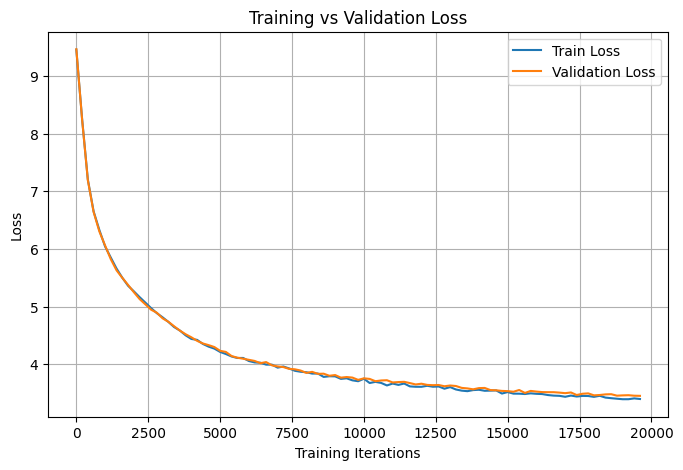

In [14]:
import matplotlib.pyplot as plt

# 🔥 No need for .cpu().detach() (losses are already floats)
train_loss_list_converted = train_loss_list
validation_loss_list_converted = validation_loss_list

# 🔥 X-axis based on evaluation frequency
steps = [i * eval_iters for i in range(len(train_loss_list_converted))]

plt.figure(figsize=(8, 5))

plt.plot(steps, train_loss_list_converted, label='Train Loss')
plt.plot(steps, validation_loss_list_converted, label='Validation Loss')

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [15]:
import torch

# 🔥 Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# 🔥 Recreate model
model = GPT(config).to(device)

# 🔥 Load checkpoint
best_model_params_path = "best_model_params.pt"
checkpoint = torch.load(best_model_params_path, map_location=device)

# 🔥 Handle both cases (state_dict OR full checkpoint)
if "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
else:
    model.load_state_dict(checkpoint)

# 🔥 Set eval mode
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [16]:
import torch
import tiktoken

enc = tiktoken.get_encoding("gpt2")

# 🔥 Use dataset-style prompt
sentence = "User: I feel dizzy and nauseous\nAssistant:"

# 🔥 Encode + move to device
context = torch.tensor(
    enc.encode_ordinary(sentence),
    dtype=torch.long
).unsqueeze(0).to(device)

# 🔥 Generate
y = model.generate(
    context,
    max_new_tokens=150,
    temperature=0.7,   # 🔥 better for medical responses
    top_k=40           # 🔥 reduces randomness
)

# 🔥 Decode
output = enc.decode(y[0].tolist())
print(output)

User: I feel dizzy and nauseous
Assistant: Hello, I am Chat Doctor, I have read your question and understand your concerns. These symptoms are related to anxiety. In my opinion, you should not worry about this. Furthermore, you should first get done anxiety test to rule out these causes. So get done stress test, stress test, stress test, stress test, stress test, ECG, chest x-ray to rule out cardiac cause. If all these are normal then no need to worry about heart diseases. You are having symptoms like dizziness, dizziness, dizziness, dizziness, chest pain etc. are common symptoms of syncope. So better to get done ECG, 2d echo and stress test (trade mill test). If all are normal then no need to
